<a href="https://colab.research.google.com/github/Nicolas-Bernal/Simulacion-Estadistica/blob/main/Primer%20Corte/0_Taller.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Taller Nicolas Alexander Bernal Rubio

# Paula Andrea Castellano

## Simulacion Estadistica

# 1. Aplicar metodo de inversion


---



## **werbull($\alpha$,1)**

### Función de Densidad de Probabilidad (f.d.p.)
Dado $X \sim \text{Weibull}(\alpha, 1)$ para $x > 0$ y $\alpha > 0$:

$$f_X(x) = \alpha x^{\alpha - 1} e^{-x^\alpha}$$

### Función de Distribución Acumulada (F.D.A.)
Integramos la densidad desde el límite inferior $0$ hasta $x$:

$$F_X(x) = \int_{0}^{x} \alpha t^{\alpha - 1} e^{-t^\alpha} \, dt$$

Haciendo el cambio de variable $u = t^\alpha \implies du = \alpha t^{\alpha - 1} dt$:

$$F_X(x) = \int_{0}^{x^\alpha} e^{-u} \, du = \left[ -e^{-u} \right]_{0}^{x^\alpha} = -e^{-x^\alpha} - (-e^0)$$

$$F_X(x) = 1 - e^{-x^\alpha}$$

### Inversión (Despeje de $x$)
Igualamos la F.D.A. a una variable aleatoria uniforme $U \sim \text{Unif}(0,1)$:

$$U = 1 - e^{-x^\alpha}$$

$$e^{-x^\alpha} = 1 - U$$

$$\ln(e^{-x^\alpha}) = \ln(1 - U)$$

$$-x^\alpha = \ln(1 - U)$$

$$x^\alpha = -\ln(1 - U)$$

$$x = \left(-\ln(1 - U)\right)^{\frac{1}{\alpha}}$$

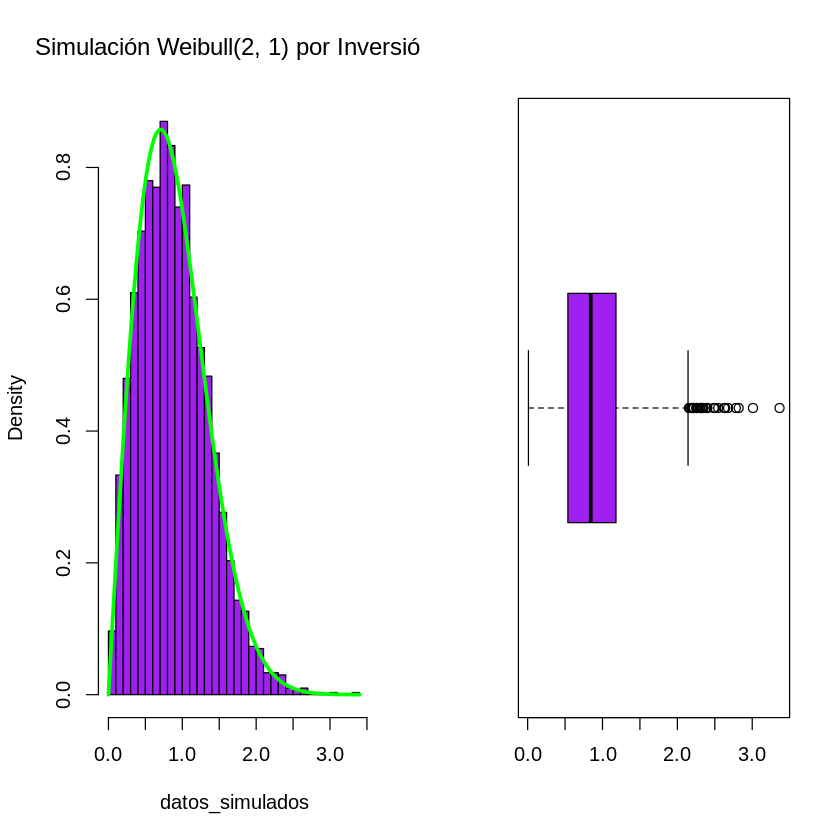

In [10]:
geneweibull = function(nsim, alpha) {
  u = runif(nsim)
  x = (-log(u))^(1 / alpha)
  return(x)
}

nsim = 3000

alpha = 2
datos_simulados = geneweibull(nsim, alpha)

par(mfrow = c(1,2))
hist(datos_simulados, freq = FALSE, breaks = "FD", col = "purple",main = substitute(paste("Simulación Weibull(", alpha, ", 1) por Inversión"), list(alpha = alpha)))
curve(dweibull(x, shape = alpha, scale = 1), add = TRUE, col = "green", lwd = 3)
boxplot(datos_simulados, horizontal = TRUE,col = "purple")

## Observaciones

* Graficamente se puede observar que la funcion con que contruimos con el metodo inverso esta generando los datos esperados con una distribucion werbull

## **Gumbel(0,1)**

### Función de Densidad de Probabilidad (f.d.p.)
Dado $X \sim \text{Gumbel}(0, 1)$:

$$f_X(x) = e^{-x} e^{-e^{-x}}$$

### Función de Distribución Acumulada (F.D.A.)
Integramos la densidad desde $-\infty$ hasta $x$:

$$F_X(x) = \int_{-\infty}^{x} e^{-t} e^{-e^{-t}} \, dt$$

Haciendo el cambio de variable $u = e^{-t} \implies du = -e^{-t} dt$:
* Cuando $t \to -\infty \implies u \to \infty$
* Cuando $t = x \implies u = e^{-x}$

$$F_X(x) = \int_{\infty}^{e^{-x}} -e^{-u} \, du = \int_{e^{-x}}^{\infty} e^{-u} \, du = \left[ -e^{-u} \right]_{e^{-x}}^{\infty} = 0 - (-e^{-e^{-x}})$$

$$F_X(x) = e^{-e^{-x}}$$

### Inversión (Despeje de $x$)
Igualamos la F.D.A. a una variable aleatoria uniforme $U \sim \text{Unif}(0,1)$:

$$U = e^{-e^{-x}}$$

Aplicamos logaritmo natural ($\ln$) en ambos lados:

$$\ln(U) = -e^{-x}$$

Multiplicamos por $-1$:

$$-\ln(U) = e^{-x}$$

Aplicamos logaritmo natural nuevamente:

$$\ln(-\ln(U)) = -x$$

Despejamos $x$:

$$x = -\ln(-\ln(U))$$

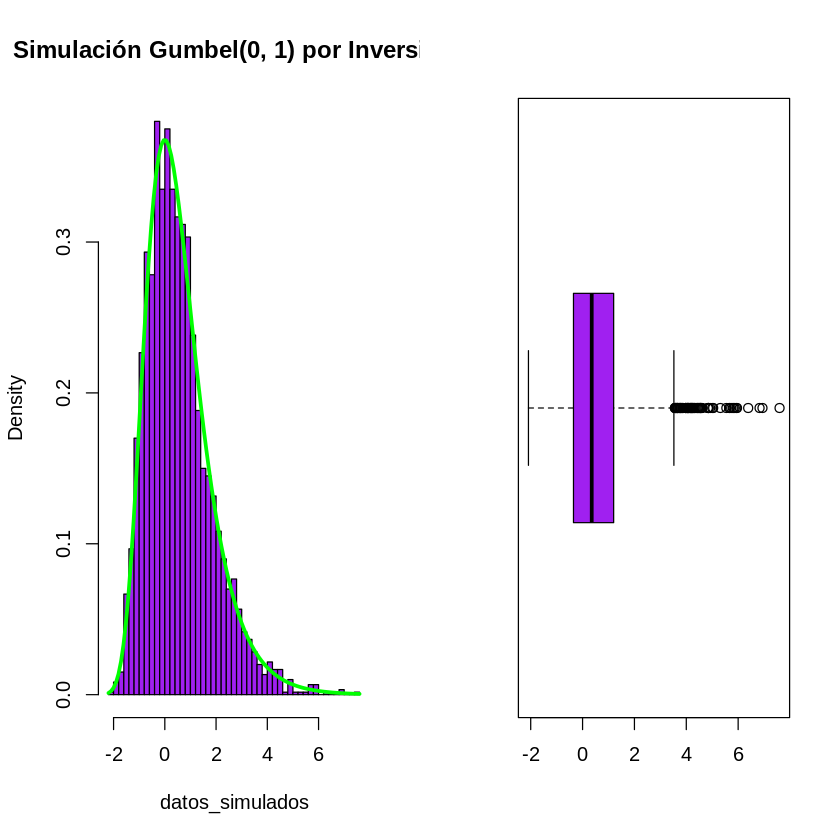

In [13]:
genergumbel = function(nsim) {
  u = runif(nsim)
  x = -log(-log(u))
  return(x)
}

nsim = 3000
datos_simulados = genergumbel(nsim)

dgumbel_n = function(x) {
  exp(-x) * exp(-exp(-x))
}

par(mfrow = c(1,2))
hist(datos_simulados, freq = FALSE, breaks = "FD", col = "purple",main = "Simulación Gumbel(0, 1) por Inversión")
curve(dgumbel_n(x), add = TRUE, col = "green", lwd = 3)
boxplot(datos_simulados,horizontal = TRUE,col = "purple")

## Observaciones

* Graficamente se puede observar que la funcion con que contruimos con el metodo inverso esta generando los datos esperados con una distribucion gumbel

## Pareto($\alpha$)

### Función de Densidad de Probabilidad (f.d.p.)
Dado $X \sim \text{Pareto}(\alpha, 1)$ para $x \ge 1$ y $\alpha > 0$:

$$f_X(x) = \frac{\alpha}{x^{\alpha + 1}}$$

### Función de Distribución Acumulada (F.D.A.)
Integramos la densidad desde el límite inferior $1$ hasta $x$:

$$F_X(x) = \int_{1}^{x} \frac{\alpha}{t^{\alpha + 1}} \, dt = \int_{1}^{x} \alpha t^{-\alpha - 1} \, dt$$

$$F_X(x) = \left[ -t^{-\alpha} \right]_{1}^{x} = -x^{-\alpha} - (-1^{-\alpha})$$

$$F_X(x) = 1 - x^{-\alpha}$$

### Inversión (Despeje de $x$)
Igualamos la F.D.A. a una variable aleatoria uniforme $U \sim \text{Unif}(0,1)$:

$$U = 1 - x^{-\alpha}$$

$$x^{-\alpha} = 1 - U$$

Elevamos ambos lados a la potencia $-\frac{1}{\alpha}$:

$$(x^{-\alpha})^{-\frac{1}{\alpha}} = (1 - U)^{-\frac{1}{\alpha}}$$

$$x = (1 - U)^{-\frac{1}{\alpha}} = \frac{1}{(1 - U)^{\frac{1}{\alpha}}}$$


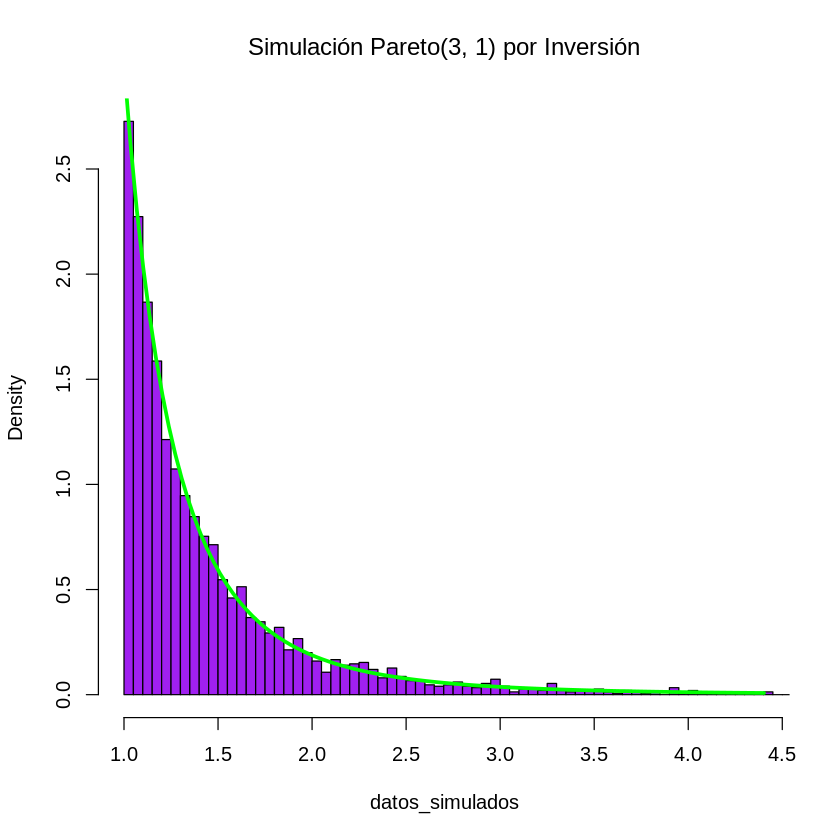

In [25]:
gen_pareto_inversion <- function(nsim, alpha) {
  u <- runif(nsim)
  x <- (1 - u)^(-1 / alpha)
  return(x)
}
dpareto_n = function(x, alpha) {
  ifelse(x >= 1, alpha / (x^(alpha + 1)), 0)
}

nsim = 3000
alpha = 3
datos_simulados = gen_pareto_inversion(nsim, alpha)


hist(datos_simulados, freq = FALSE, breaks = "FD",col = "purple",xlim = c(1, quantile(datos_simulados, 0.99)),main = substitute(paste("Simulación Pareto(", alpha, ", 1) por Inversión"), list(alpha = alpha)))

curve(dpareto_std(x, alpha), add = TRUE, col = "green", lwd = 3)

## Observaciones

* Graficamente se puede observar que la funcion con que contruimos con el metodo inverso esta generando los datos esperados con una distribucion pareto

#